In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('master_dataset_interim.csv')
df['word_count'] = df['message'].str.split().str.len()
df['char_count'] = df['message'].str.len()
df['fake_label'] = (
    (df['word_count'] <= 3) & (df['rating'] == 5) & (df['is_anonymous'] == True)
).map({True: 'Fake', False: 'Genuine'})
df['sentiment'] = df['rating'].map({1:'Negatif',2:'Negatif',3:'Netral',4:'Positif',5:'Positif'})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('=== Statistik Dasar ===')
print(df[['rating','word_count','char_count','total_likes']].describe().round(2))
print()
print('=== Distribusi Fake vs Genuine ===')
print(df['fake_label'].value_counts())
print()
print('=== Distribusi Rating ===')
print(df['rating'].value_counts().sort_index())

Shape: (10100, 17)
Columns: ['product_name', 'id', 'rating', 'message', 'date', 'timestamp', 'variant', 'is_anonymous', 'username', 'total_likes', 'has_image', 'has_video', 'seller_reply', 'word_count', 'char_count', 'fake_label', 'sentiment']

=== Statistik Dasar ===
         rating  word_count  char_count  total_likes
count  10100.00    10100.00    10100.00     10100.00
mean       4.43        9.68       58.61         0.02
std        1.12        8.91       52.97         0.23
min        1.00        1.00        1.00         0.00
25%        4.00        4.00       22.00         0.00
50%        5.00        7.00       44.00         0.00
75%        5.00       13.00       77.00         0.00
max        5.00       78.00      514.00        13.00

=== Distribusi Fake vs Genuine ===
fake_label
Genuine    8158
Fake       1942
Name: count, dtype: int64

=== Distribusi Rating ===
rating
1     622
2     292
3     503
4    1409
5    7274
Name: count, dtype: int64


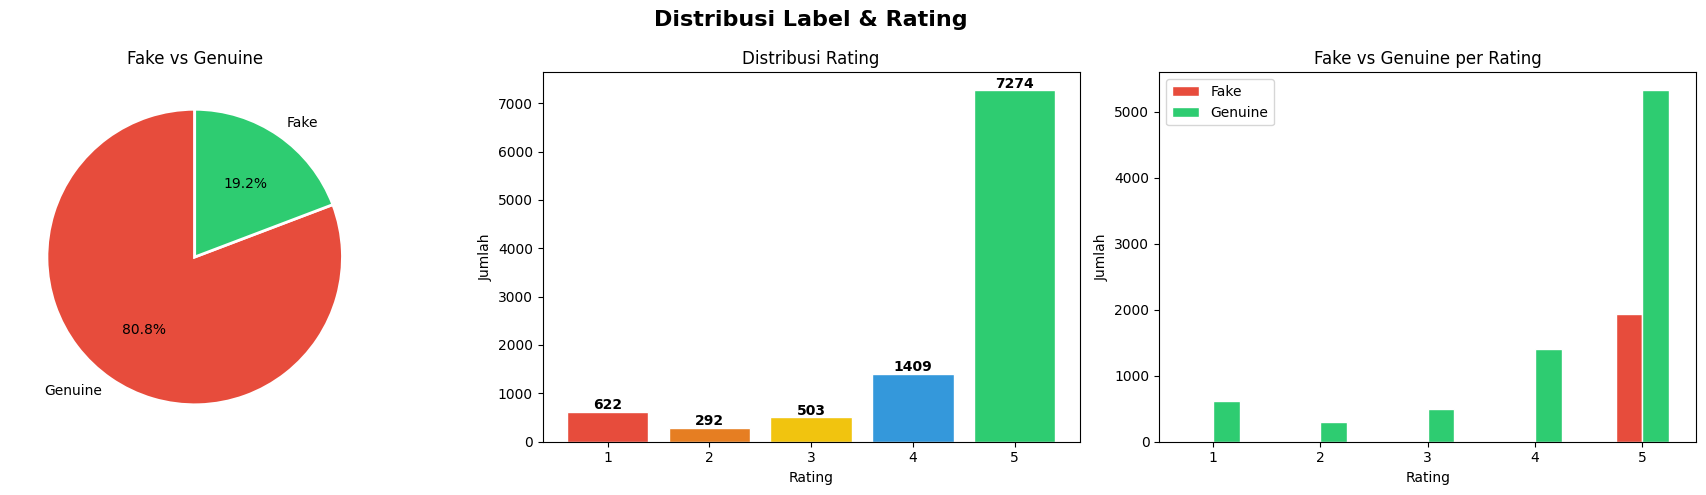

In [7]:
# ── Visualisasi 1: Rating & Fake/Genuine ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Label & Rating', fontsize=16, fontweight='bold')

# Pie chart
label_counts = df['fake_label'].value_counts()
axes[0].pie(label_counts, labels=label_counts.index,
            colors=['#E74C3C','#2ECC71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Fake vs Genuine')

# Rating histogram
colors = ['#E74C3C','#E67E22','#F1C40F','#3498DB','#2ECC71']
rating_counts = df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Distribusi Rating')
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Jumlah')
for i, v in enumerate(rating_counts.values):
    axes[1].text(i+1, v+50, str(v), ha='center', fontweight='bold')

# Fake per rating
cross = df.groupby(['rating','fake_label']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[2], color=['#E74C3C','#2ECC71'],
           edgecolor='white', rot=0)
axes[2].set_title('Fake vs Genuine per Rating')
axes[2].set_xlabel('Rating'); axes[2].set_ylabel('Jumlah')
axes[2].legend()

plt.tight_layout()
plt.savefig('viz_rating_label.png', dpi=150, bbox_inches='tight')
plt.show()

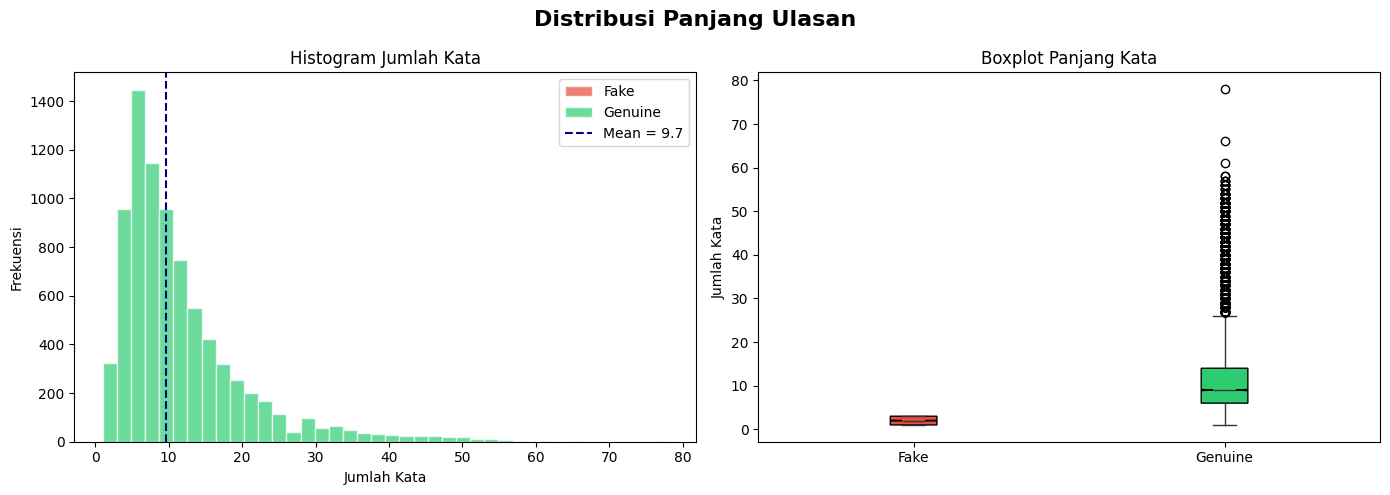

In [8]:
# ── Visualisasi 2: Panjang Ulasan ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Ulasan', fontsize=16, fontweight='bold')

# Histogram word count
for label, color in [('Fake','#E74C3C'), ('Genuine','#2ECC71')]:
    axes[0].hist(df[df['fake_label']==label]['word_count'],
                 bins=40, alpha=0.7, color=color, label=label, edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='navy', linestyle='--',
                label=f"Mean = {df['word_count'].mean():.1f}")
axes[0].set_title('Histogram Jumlah Kata'); axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi'); axes[0].legend()

# Boxplot
fake_wc    = df[df['fake_label']=='Fake']['word_count']
genuine_wc = df[df['fake_label']=='Genuine']['word_count']
bp = axes[1].boxplot([fake_wc, genuine_wc], labels=['Fake','Genuine'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#E74C3C')
bp['boxes'][1].set_facecolor('#2ECC71')
for item in ['whiskers','caps','medians','fliers']:
    plt.setp(bp[item], color='#333')
axes[1].set_title('Boxplot Panjang Kata'); axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.savefig('viz_word_length.png', dpi=150, bbox_inches='tight')
plt.show()

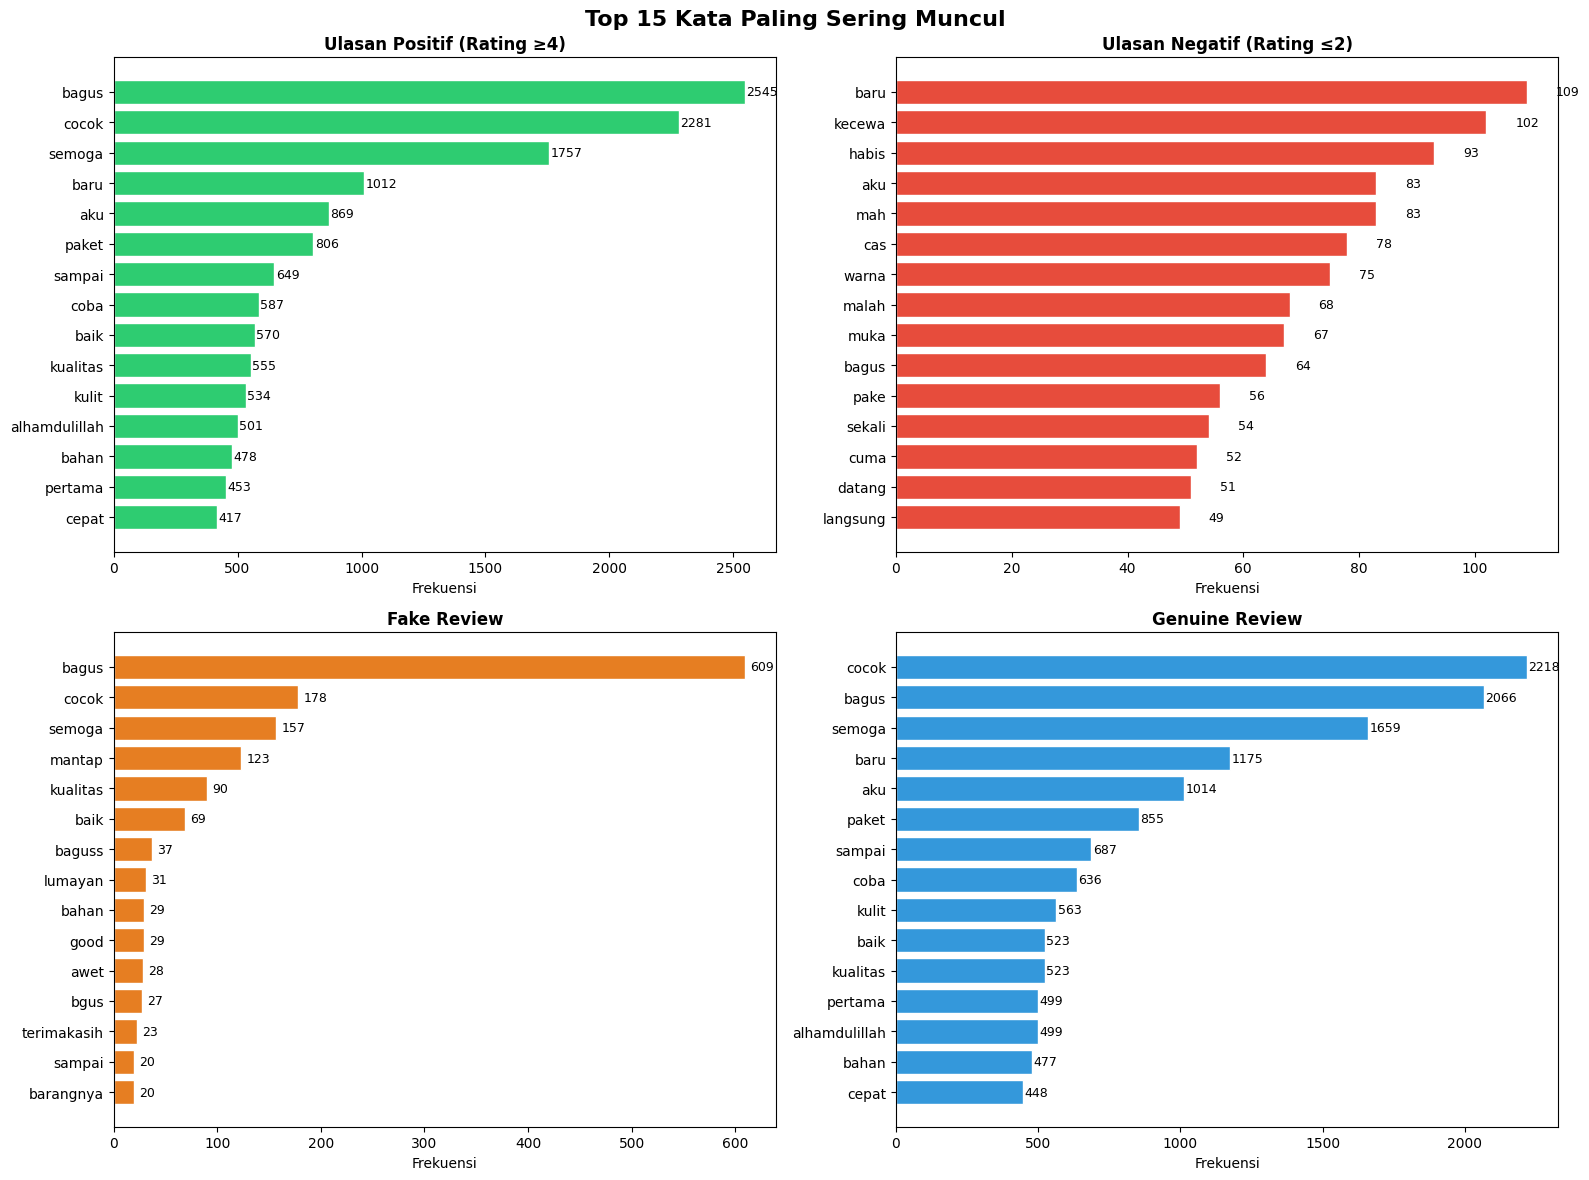

In [9]:
# ── Visualisasi 3: Top Words ───────────────────────────────────────────────
STOPWORDS = {
    'yang','dan','di','ke','dari','ini','itu','dengan','untuk','adalah','ada',
    'pada','tidak','nya','saya','sudah','belum','sangat','banget','juga','tapi',
    'kalo','kalau','bisa','karena','jadi','karna','pas','ya','si','se','ga',
    'gak','nggak','bgt','sy','lg','dg','tp','dr','utk','dgn','sdh','blm','krn',
    'lagi','aja','sih','lebih','atau','pun','harga','produk','barang','pesanan',
    'pengiriman','beli','sesuai','packing','oke','ok','nya','yg','ke','di','an',
    'lah','deh','jg','udah','udh','emang','memang','mau','nih','kan','saja',
    'sama','itu','satu','dua','tiga'
}

def top_words(texts, n=15):
    all_words = []
    for t in texts:
        words = re.findall(r'[a-z]+', str(t).lower())
        all_words.extend([w for w in words if w not in STOPWORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 15 Kata Paling Sering Muncul', fontsize=16, fontweight='bold')

configs = [
    (df[df['rating']>=4]['message'],    '#2ECC71', 'Ulasan Positif (Rating ≥4)',  axes[0][0]),
    (df[df['rating']<=2]['message'],    '#E74C3C', 'Ulasan Negatif (Rating ≤2)',  axes[0][1]),
    (df[df['fake_label']=='Fake']['message'], '#E67E22', 'Fake Review',           axes[1][0]),
    (df[df['fake_label']=='Genuine']['message'],'#3498DB','Genuine Review',       axes[1][1]),
]

for texts, color, title, ax in configs:
    freq = top_words(texts)
    if not freq: continue
    words, counts = zip(*freq)
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    for bar, val in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

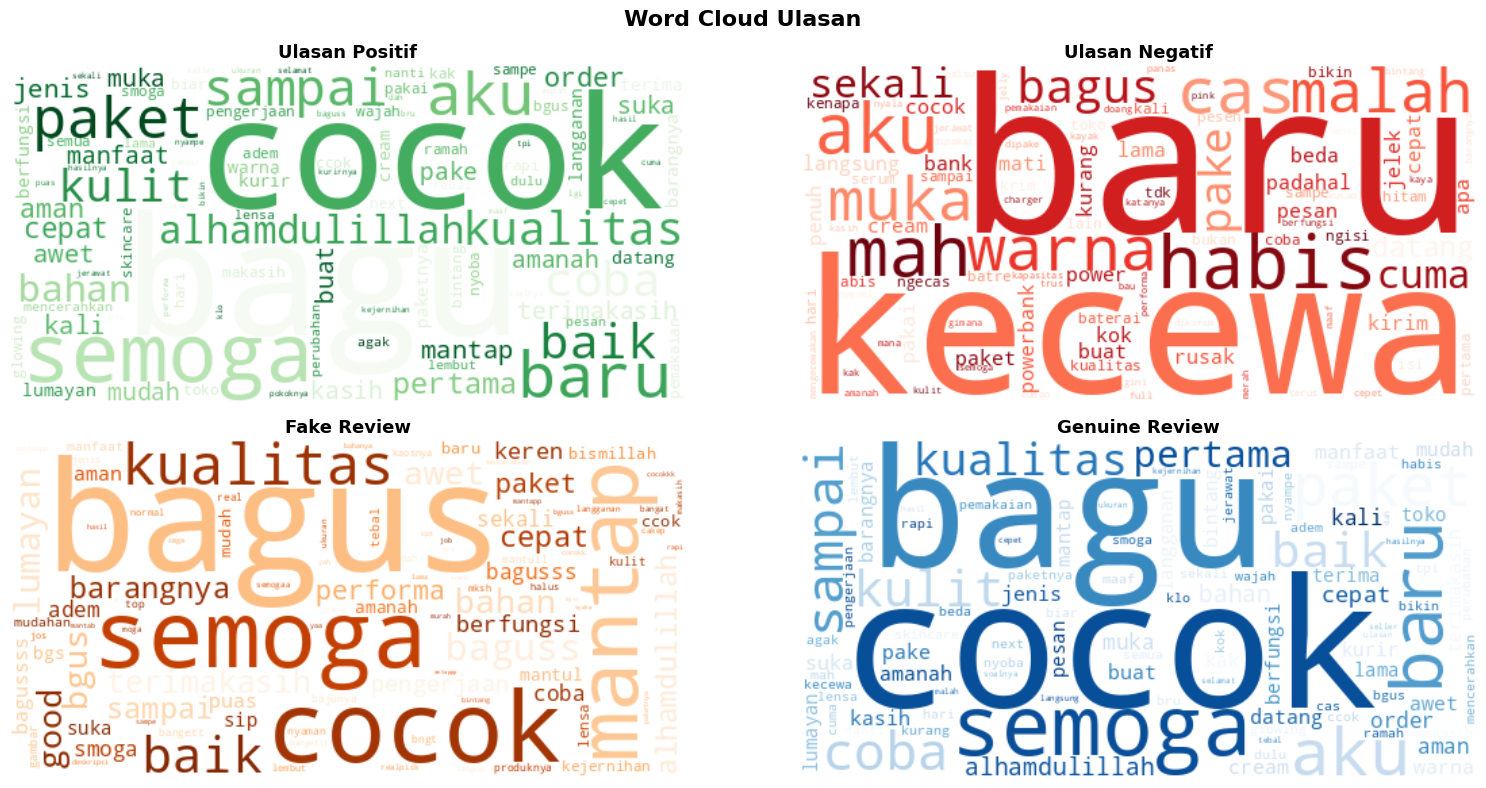

In [10]:
# ── Visualisasi 4: Word Cloud ──────────────────────────────────────────────
from wordcloud import WordCloud

def make_wc(texts, colormap):
        combined = ' '.join(
            w for t in texts
            for w in re.findall(r'[a-z]+', str(t).lower())
            if w not in STOPWORDS and len(w) > 2
        )
        return WordCloud(width=500, height=250, background_color='white',
                         colormap=colormap, max_words=100,
                         collocations=False).generate(combined)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Word Cloud Ulasan', fontsize=16, fontweight='bold')

configs_wc = [
        (df[df['rating']>=4]['message'],         'Greens',  'Ulasan Positif',  axes[0][0]),
        (df[df['rating']<=2]['message'],          'Reds',   'Ulasan Negatif',  axes[0][1]),
        (df[df['fake_label']=='Fake']['message'], 'Oranges','Fake Review',     axes[1][0]),
        (df[df['fake_label']=='Genuine']['message'],'Blues','Genuine Review',  axes[1][1]),
    ]

for texts, cmap, title, ax in configs_wc:
        wc = make_wc(texts, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('viz_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Download semua visualisasi ─────────────────────────────────────────────
import zipfile, os
from google.colab import files

viz_files = ['viz_rating_label.png','viz_word_length.png',
             'viz_top_words.png','viz_wordcloud.png']
viz_files = [f for f in viz_files if os.path.exists(f)]

with zipfile.ZipFile('eda_visualizations.zip', 'w') as z:
    for f in viz_files:
        z.write(f)

files.download('eda_visualizations.zip')
print(f'✅ Berhasil download {len(viz_files)} visualisasi!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Berhasil download 4 visualisasi!
